In [1]:
from obspy import *
import pandas as pd
import matplotlib.pyplot as plt
from obspy.clients.fdsn import Client
import matplotlib.dates as mdates
import numpy as np
import datetime
from obspy.signal.cross_correlation import correlation_detector

This is the calving event that Riley caught on camera. 

In [2]:
#Mar Piedmont Glacier Calving Event
#%run palmer_picker.py 2026-03-03T15:11 2026-03-03T15:11:30

#st.spectrogram()
#st.plot(equal_scale=False)
#for item in st:
    #item.write(f"{item.stats.station+ st[0].stats.starttime.strftime('%m-%dT%H:%M')}.mseed", format="MSEED")

Installed new opener with handlers: [<urllib.request.HTTPDigestAuthHandler object at 0x32af432d0>, <obspy.clients.fdsn.client.NoRedirectionHandler object at 0x389f1b050>]
Base URL: http://10.30.5.28:8080
Request Headers: {'User-Agent': 'ObsPy/1.5.0 (macOS-26.5.1-arm64-arm-64bit, Python 3.11.14)'}
Loading discovered services from cache.
Downloaded http://10.30.5.28:8080/fdsnws/dataselect/1/queryauth?starttime=2026-04-03T03%3A21%3A30.000000&endtime=2026-04-03T05%3A22%3A20.000000&network=%2A&station=I54H2&location=%2A&channel=BDF with HTTP code: 200
Downloaded http://10.30.5.28:8080/fdsnws/station/1/query?starttime=2026-04-03T03%3A20%3A54.850000&endtime=2026-04-03T05%3A23%3A23.550000&network=IM&station=I54H2&location=--&channel=BDF&level=response with HTTP code: 200


/Users/kitsellusted/grad_school/VANDA_work/palmer_picker.py:51: ObsPyDeprecationWarning: attach_response is deprecated and will be removed in a future release. Use remove_response() instead.
  st = client2.get_waveforms(


Downloaded http://10.30.5.28:8080/fdsnws/event/1/query?starttime=2026-04-03T03%3A21%3A30.000000&endtime=2026-04-03T05%3A22%3A20.000000&minmagnitude=5.0&maxmagnitude=9.0 with HTTP code: 204
No earthquakes for this time period.


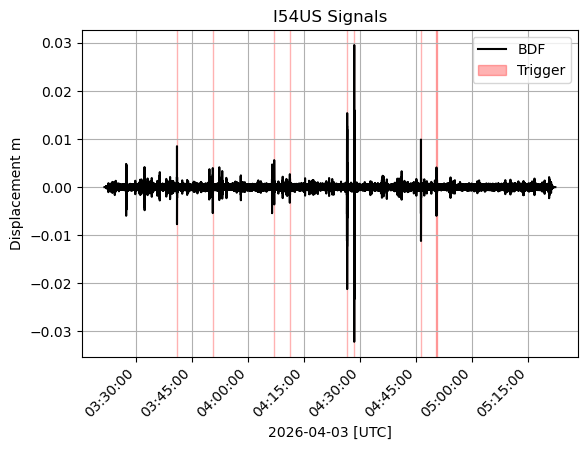

In [77]:
%run palmer_picker.py 2026-04-03T03:21:30 2026-04-03T05:22:20
#st.write('I54_wiggle.mseed', format = "MSEED")
#st.plot()
#len(trig_times)

In [4]:
def stat_plotter(df):
    #Calculate hourly/daily metrics
    hourly_counts = df.groupby(df['local'].dt.hour).size() #in local time
    hour_utc = df.groupby(df['onset'].dt.hour).size() #UTC
    daily_counts = df.groupby(df['local'].dt.day).size() #in local time
    daily_utc = df.groupby(df['onset'].dt.day).size()

    #Plot hourly variation of signal detection
    fig, ax = plt.subplots()
    ax.scatter(df['hour_local'].unique(), hourly_counts, label = 'Palmer Events') #local time
    ax.set_xlabel('Hours in Local Time (UTC-3)')
    ax.set_ylabel('Number of Triggers')
    ax.legend()
    fig.suptitle('Triggers Grouped by Time of Day unfiltered vs filtered')
    
    
    #pick_5 = daily_utc/(24*60) #event time put y-axis in pick per 5 ish min, or pick per minute
    fig, ax = plt.subplots()
    #ax.scatter(pd.to_datetime(df['onset']).dt.date.unique(), daily_utc)
    ax.scatter(pd.to_datetime(df['onset']).dt.date.unique(), daily_utc/(24), label = 'unfiltered') #pick per hour
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.set_xlabel('Days in UTC Time')
    #ax.set_ylim(5,15)
    ax.set_title("Average Number of Events per Hour")
    ax.set_ylabel('Number of Triggers per Hour')
    ax.legend()
    
    fig.tight_layout(pad=3.0) 

    fig.add_gridspec(4, 4, wspace=0, hspace=0)
   
    #interevent time plot
   
    fig, ax = plt.subplots()
    #ax.scatter(pd.to_datetime(df['onset']).dt.date.unique(), daily_utc)
    ax.hist(df['interevent_time'].dt.total_seconds()/60, bins = 80, edgecolor = 'black', label = 'unfiltered') 
    #ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.set_xlabel('Time in Minutes')
    ax.set_title("Interevent Spacing")
    ax.set_ylabel('Occurances')
    ax.legend()
    plt.show()

    fig, ax = plt.subplots()

    #ax = df.groupby(pd.Grouper(key='onset', freq='h')).size().plot(color = 'blue')
    ax = hourly_counts.plot(color = 'red', label = 'filtered')
    ax.set_xlabel('Days in UTC Time')
    ax.set_title("Number of Events per Hour")
    ax.set_ylabel('Number of Triggers per hour')
    #ax.set_ylim(0, 25)
    fig.tight_layout(pad=3.0) 
    fig.legend()
    fig.add_gridspec(8, 8, wspace=0, hspace=0)

    return None
    

In [5]:
trig_times[-1]

[2026-04-09T23:33:27.150000Z, 2026-04-09T23:33:28.550000Z]

In [75]:
#Trigger dataframe stuff
trigger_df = pd.DataFrame(trig_times)

#trigger_df.set_index()
trigger_df[0] = [t.datetime for t in trigger_df[0]]
trigger_df[1] = [t.datetime for t in trigger_df[1]]
trigger_df['month'] = trigger_df[0].dt.month
trigger_df['day'] = trigger_df[0].dt.day
trigger_df['hour_UTC'] = trigger_df[0].dt.hour

#Times in local Antarctica time, better for daylight tracking, diurnal patterns
trigger_df['local'] = trigger_df[0].dt.tz_localize('UTC').dt.tz_convert('Antarctica/Palmer')
trigger_df['hour_local'] = trigger_df['local'].dt.hour
trigger_df['day_local'] = trigger_df['local'].dt.day
trigger_df.rename(columns={0:'onset', 1:'offset'}, inplace = True)

#Interevent spacing
trigger_df['interevent_time'] = trigger_df['onset'].shift(-1) - trigger_df['offset']
trigger_df['interevent_time'] = trigger_df['interevent_time'].mask(trigger_df['interevent_time'] < pd.to_timedelta(100, unit='s'))

#Hourly and Daily counts
trigger_df["hourly_counts"] = trigger_df.groupby(trigger_df['local'].dt.hour).size() #in local time
hour_utc = trigger_df.groupby(trigger_df['onset'].dt.hour).size() #UTC
daily_counts = trigger_df.groupby(trigger_df['local'].dt.day).size() #in local time
daily_utc = trigger_df.groupby(trigger_df['onset'].dt.day).size()
#trigger_df['amplitude m'] = pd.DataFrame(peak_amps) #amplitude - displacement in meters

trigger_df

,onset,offset,month,day,hour_UTC,local,hour_local,day_local,interevent_time,hourly_counts
0,2026-04-03 03:21:48.000,2026-04-03 03:21:49.650,4,3,3,2026-04-03 00:21:48-03:00,0,3,NaT,4.0
1,2026-04-03 03:21:57.250,2026-04-03 03:21:57.800,4,3,3,2026-04-03 00:21:57.250000-03:00,0,3,NaT,NaN
2,2026-04-03 03:22:04.650,2026-04-03 03:22:05.550,4,3,3,2026-04-03 00:22:04.650000-03:00,0,3,NaT,NaN
3,2026-04-03 03:22:19.600,2026-04-03 03:22:20.000,4,3,3,2026-04-03 00:22:19.600000-03:00,0,3,NaT,NaN


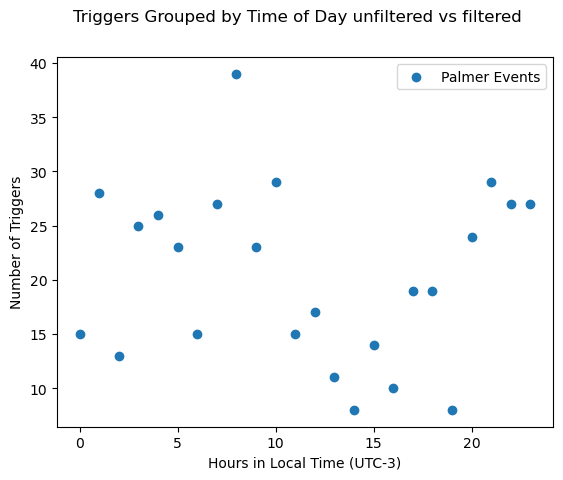

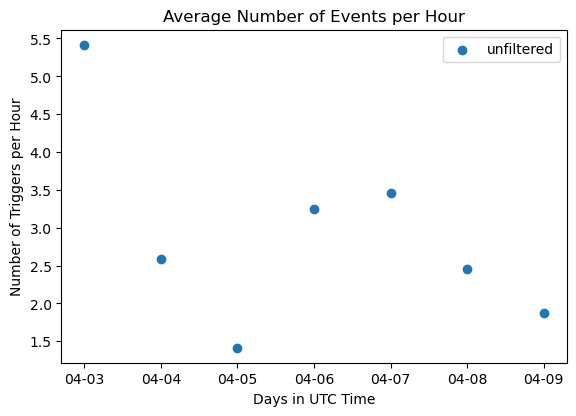

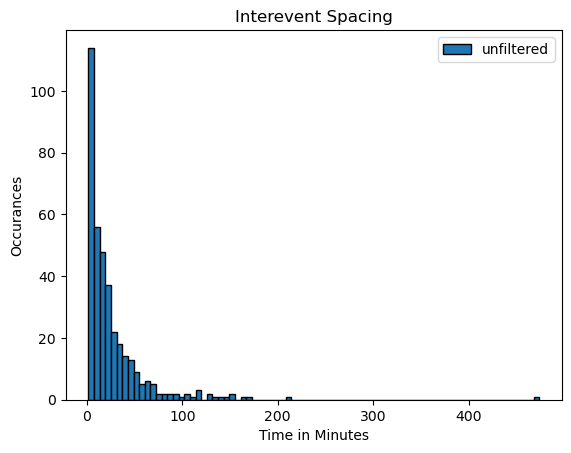

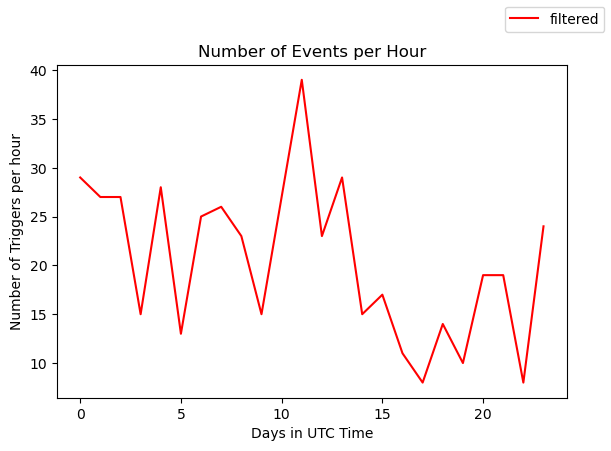

In [7]:
# COMPARING THE FILTERED VS. UNFILTERED TRIGGER PICKS. FILTERING BY TIME INBETWEEN TRIGGERS
#adding in the additional filter by amplitude reduces the likelihood of double picking!
stat_plotter(trigger_df)


In [ ]:
    fig, ax = plt.subplots()
    ax.scatter(df['hour_local'].unique(), hourly_counts, label = 'Palmer Events') #local time
    ax.set_xlabel('Hours in Local Time (UTC-3)')
    ax.set_ylabel('Number of Triggers')
    ax.legend()
    fig.suptitle('Triggers Grouped by Time of Day unfiltered vs filtered')
    

## Preparing for Template Matching ##

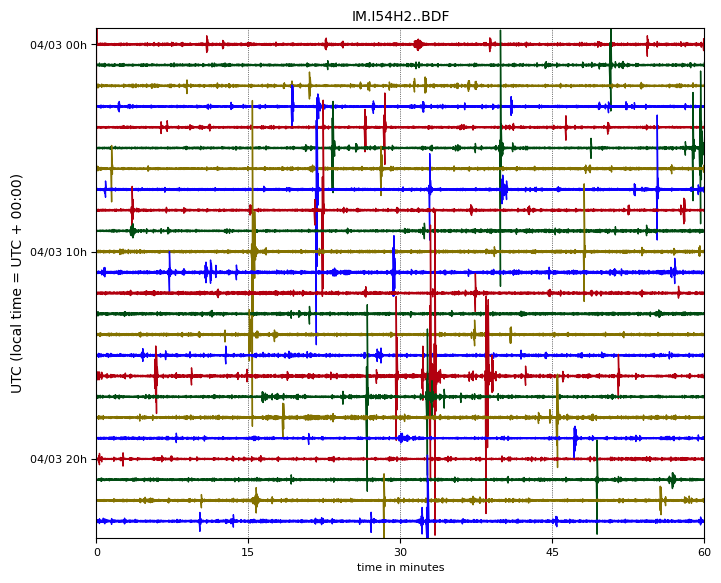

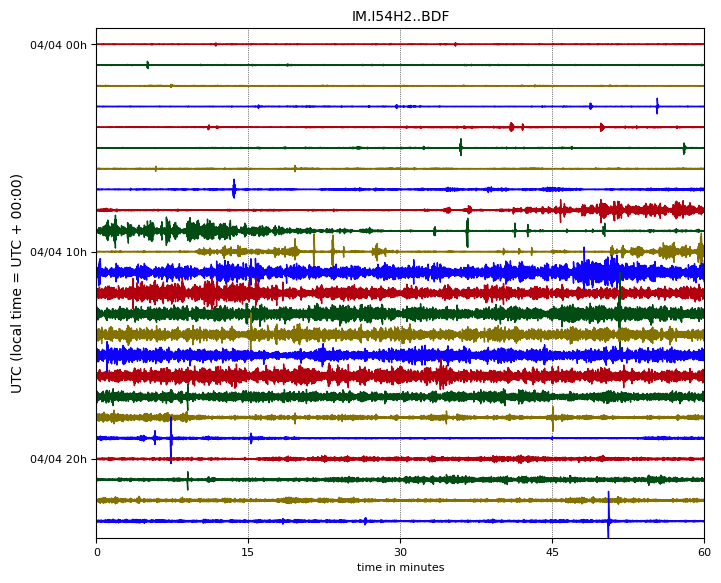

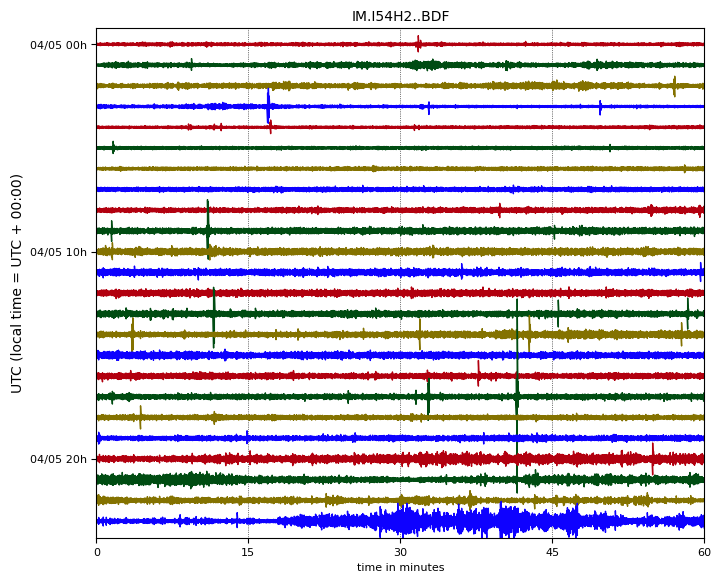

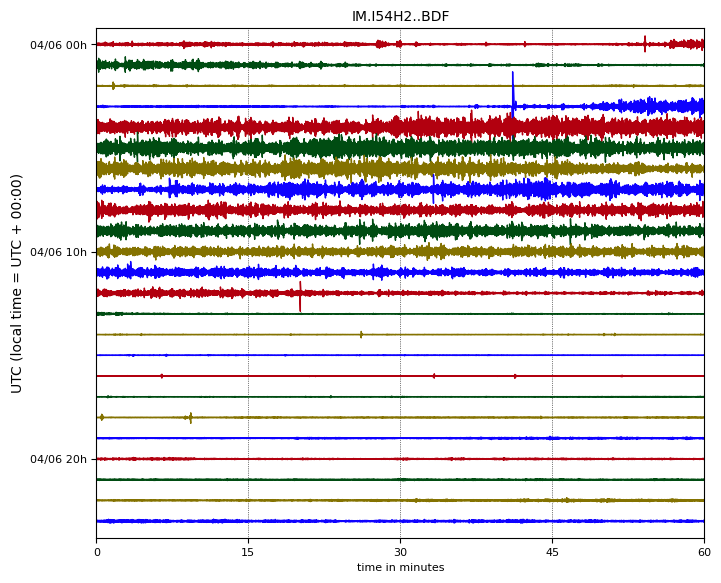

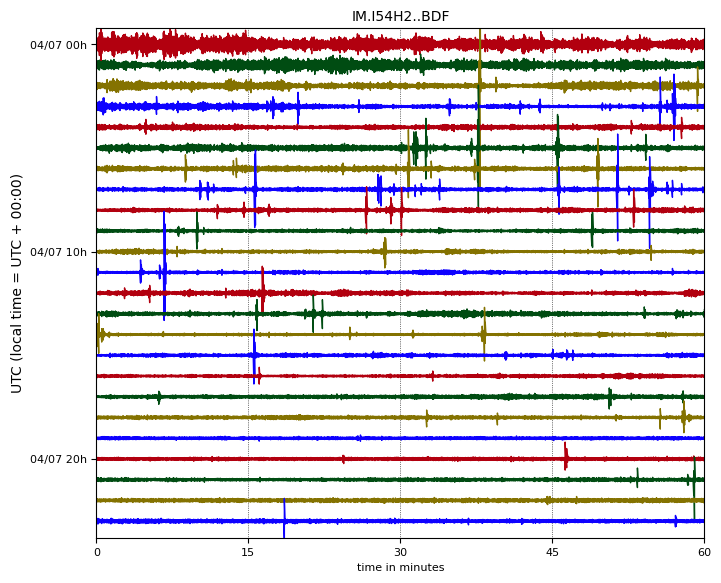

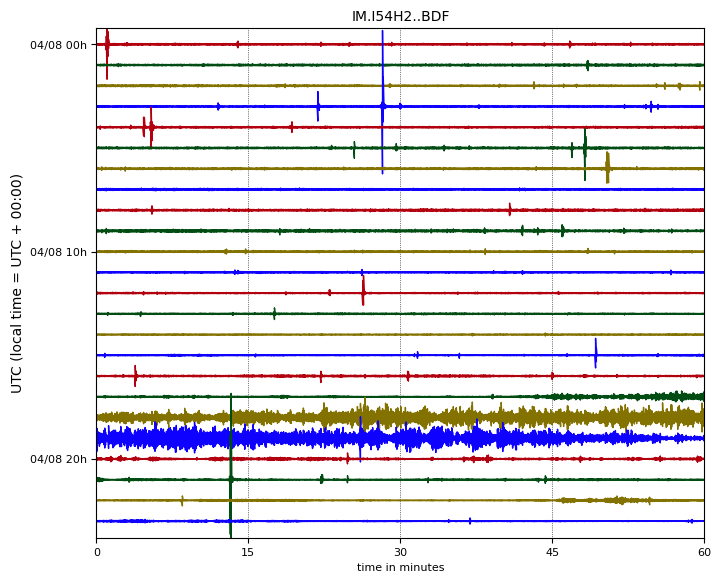

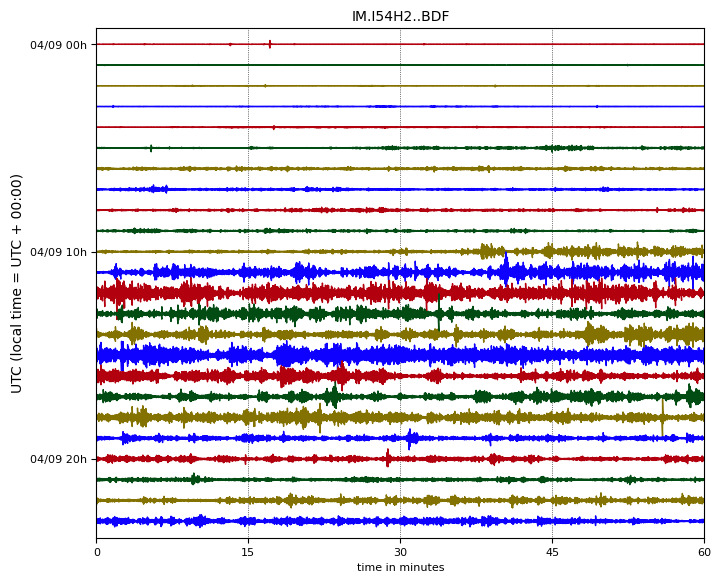

In [8]:
#Dayplots
#st.filter("bandpass", freqmin=2, freqmax=8)
for tr in st:
    for i in range(len(pd.to_datetime(trigger_df['onset']).dt.date.unique())):
        start_time = st[0].stats.starttime
        day_start = start_time + (i * 86400)
        day_end = day_start + 86400
        daily_st = st.slice(day_start, day_end)
        local_offset = +13 * 3600
        daily_st.plot(type='dayplot', interval=60, tick_format='%m/%d %Hh', 
                      offset=local_offset,
                      show_y_UTC_label=True  )# interval is minutes per line


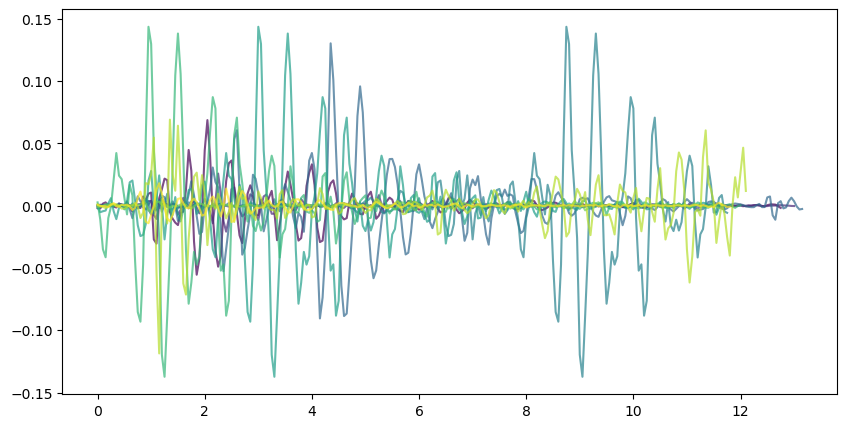

In [67]:
#len(sliced_wvf)
i = 0
fig,ax = plt.subplots(figsize=(10,5))
time = sliced_wvf[0]
for i, tr in enumerate(sliced_wvf):
    cmap = plt.colormaps['viridis']
    #print(tr)
    # Generate a list of 12 RGBA tuples evenly sampled from 0 to 1
    
    color_list = [cmap(i) for i in np.linspace(0, 1, len(sliced_wvf))]
    ax.plot(tr.times(), tr.data, color=color_list[i], alpha = 0.7, label='Original')
    i +=1 
        #s.plot()

Installed new opener with handlers: [<urllib.request.HTTPDigestAuthHandler object at 0x38984d010>, <obspy.clients.fdsn.client.NoRedirectionHandler object at 0x38984fd50>]
Base URL: http://10.30.5.28:8080
Request Headers: {'User-Agent': 'ObsPy/1.5.0 (macOS-26.5.1-arm64-arm-64bit, Python 3.11.14)'}
Loading discovered services from cache.
Downloaded http://10.30.5.28:8080/fdsnws/dataselect/1/queryauth?starttime=2026-03-03T03%3A00%3A00.000000&endtime=2026-03-03T06%3A00%3A00.000000&network=%2A&station=I54H2&location=%2A&channel=BDF with HTTP code: 200
Downloaded http://10.30.5.28:8080/fdsnws/station/1/query?starttime=2026-03-03T02%3A59%3A57.350000&endtime=2026-03-03T06%3A00%3A01.000000&network=IM&station=I54H2&location=--&channel=BDF&level=response with HTTP code: 200


/Users/kitsellusted/grad_school/VANDA_work/palmer_picker.py:51: ObsPyDeprecationWarning: attach_response is deprecated and will be removed in a future release. Use remove_response() instead.
  st = client2.get_waveforms(


Downloaded http://10.30.5.28:8080/fdsnws/event/1/query?starttime=2026-03-03T03%3A00%3A00.000000&endtime=2026-03-03T06%3A00%3A00.000000&minmagnitude=5.0&maxmagnitude=9.0 with HTTP code: 204
No earthquakes for this time period.
26
[{'time': UTCDateTime(2026, 3, 3, 3, 3, 7, 250000), 'similarity': np.float64(0.5200309086565875), 'template_id': 0}, {'time': UTCDateTime(2026, 3, 3, 3, 5, 16, 650000), 'similarity': np.float64(0.9999999999998664), 'template_id': 0}, {'time': UTCDateTime(2026, 3, 3, 3, 5, 57, 850000), 'similarity': np.float64(0.5073116174094463), 'template_id': 0}, {'time': UTCDateTime(2026, 3, 3, 3, 7, 33, 600000), 'similarity': np.float64(0.6114838961399859), 'template_id': 0}, {'time': UTCDateTime(2026, 3, 3, 3, 50, 44, 650000), 'similarity': np.float64(0.5229518299153003), 'template_id': 0}]
[{'time': UTCDateTime(2026, 3, 3, 4, 24, 18), 'similarity': np.float64(0.5105056550002917), 'template_id': 0}, {'time': UTCDateTime(2026, 3, 3, 4, 40, 14, 950000), 'similarity': np.floa

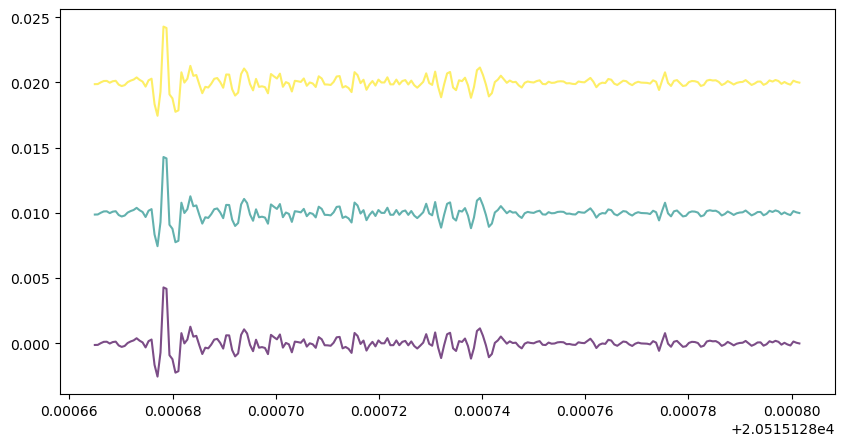

In [40]:
%run palmer_picker.py 2026-03-03T03:00 2026-03-03T06:00:00
print(len(trig_times))
starttime = st[0].stats.starttime
i = 1
ss = []
for s in sliced_wvf:
    
    while starttime < st[0].stats.endtime:
        endtime = starttime + 3600
    
        # Cap the endtime to the stream's end to prevent out-of-bounds slicing
        if endtime > st[0].stats.endtime:
            endtime = st[0].stats.endtime   
        hr = st.slice(starttime, endtime)
        if len(hr) > 0 and len(hr[0].data) > 0:
            d, sim = correlation_detector(hr, Stream(sliced_wvf[0]), 0.5, 1)
            if len(d)>1:
                print(d)
                ss.append(s)
        starttime = endtime
        i += 1
fig,ax = plt.subplots(figsize=(10,5))
i = 0
for tr in ss:
    cmap = plt.colormaps['viridis']
    print(tr)
# Generate a list of 12 RGBA tuples evenly sampled from 0 to 1
    color_list = [cmap(i) for i in np.linspace(0, 1, len(ss))]
    ax.plot(tr.times('matplotlib'), tr.data+0.01*i, color=color_list[i], alpha = 0.7, label='Original')
    i +=1 
        #s.plot()

In [27]:
len(ss)

1

In [12]:
%run palmer_picker.py 2026-03-03T00:00 2026-03-03T06:00:00
st[0].data = np.nan_to_num(st[0].data)
d, s = correlation_detector(st, Stream(sliced_wvf[0]), 0.5, 10)
print(len(trig_times),len(d))

Installed new opener with handlers: [<urllib.request.HTTPDigestAuthHandler object at 0x38c4d6f90>, <obspy.clients.fdsn.client.NoRedirectionHandler object at 0x389026390>]
Base URL: http://10.30.5.28:8080
Request Headers: {'User-Agent': 'ObsPy/1.5.0 (macOS-26.5.1-arm64-arm-64bit, Python 3.11.14)'}
Loading discovered services from cache.
Downloaded http://10.30.5.28:8080/fdsnws/dataselect/1/queryauth?starttime=2026-03-03T00%3A00%3A00.000000&endtime=2026-03-03T06%3A00%3A00.000000&network=%2A&station=I54H2&location=%2A&channel=BDF with HTTP code: 200


/Users/kitsellusted/grad_school/VANDA_work/palmer_picker.py:51: ObsPyDeprecationWarning: attach_response is deprecated and will be removed in a future release. Use remove_response() instead.
  st = client2.get_waveforms(


Downloaded http://10.30.5.28:8080/fdsnws/station/1/query?starttime=2026-03-02T23%3A59%3A47.750000&endtime=2026-03-03T06%3A00%3A01.000000&network=IM&station=I54H2&location=--&channel=BDF&level=response with HTTP code: 200
Downloaded http://10.30.5.28:8080/fdsnws/event/1/query?starttime=2026-03-03T00%3A00%3A00.000000&endtime=2026-03-03T06%3A00%3A00.000000&minmagnitude=5.0&maxmagnitude=9.0 with HTTP code: 204
No earthquakes for this time period.
44 11


/Users/kitsellusted/miniconda3/envs/pygmt-env/lib/python3.11/site-packages/obspy/signal/cross_correlation.py:291: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(norm, out=norm)
